# Strategy Lab 02 - Oscillation / residual-reversion strategy

这篇只做震荡恢复。假设最近窗口里趋势不强，价格主要围绕 `trend + cycle` 波动。

策略逻辑：

1. 先用 `abs(trend_strength)` 判断是否是弱趋势/震荡环境。
2. `fair value = exp(trend + cycle)`。
3. `residual_z < -entry_z`：价格低于当前趋势+周期结构，做多或买入。
4. `residual_z > entry_z`：价格高于当前趋势+周期结构，卖出或做空。
5. 回到 `residual_z ≈ 0` 附近退出。
6. 信号在第 t 根 bar 结束后生成，回测用下一根 bar 的开盘价成交。

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display
from quant_trading.data import load_sample_goog_ohlcv
from quant_trading.decomposition_features import walkforward_price_volume_features
from quant_trading.strategy_lab import (
    TrendFollowingConfig,
    OscillationReversionConfig,
    backtest_signal_set,
    execution_price_panel,
    decomposition_trend_following_signals,
    decomposition_oscillation_reversion_signals,
    plot_signal_analysis,
    stats_table,
)
from quant_trading.strategy_baselines import (
    buy_and_hold_weights,
    dual_moving_average_weights,
    bollinger_mean_reversion_weights,
)
from quant_trading.strategy_lab import backtest_target_weights_next_bar

CHART_DIR = Path("examples/quant_trading/reports/strategy_lab/charts")

In [2]:
ohlcv = load_sample_goog_ohlcv(trim_start="2014-01-01")
symbol = "GOOG"
close = ohlcv["Close"].rename(symbol).to_frame()
volume = ohlcv["Volume"].rename(symbol).to_frame()
execution_prices = execution_price_panel(ohlcv, field="Open", next_bar=True)
execution_prices.columns = [symbol]

features = walkforward_price_volume_features(
    close, volume, method="STL", period=126, train_window=504, step=5, z_window=63
)


In [3]:
signal = decomposition_oscillation_reversion_signals(
    close,
    features,
    config=OscillationReversionConfig(
        entry_residual_z=1.75,
        exit_residual_z=0.15,
        max_abs_trend_strength=0.35,
        require_cycle_turn=True,
        allow_short=True,
    ),
    name="detime_STL_oscillation_reversion",
)

bt = backtest_signal_set(
    close, signal, execution_prices=execution_prices, fee_bps=5, slippage_bps=2, periods_per_year=252
)

baselines = {
    "buy_hold": buy_and_hold_weights(close),
    "classic_bollinger_20_2": bollinger_mean_reversion_weights(close, window=20, entry_z=2.0, allow_short=True),
}
results = {signal.name: bt}
for name, weights in baselines.items():
    results[name] = backtest_target_weights_next_bar(
        close, weights, execution_prices=execution_prices, fee_bps=5, slippage_bps=2, periods_per_year=252, name=name
    )

stats_table(results)

,strategy,total_return,cagr,sharpe,max_drawdown,calmar,volatility,hit_rate,trade_win_rate,average_trade_directional_return,orders,round_trips,median_bars_held,average_turnover,average_gross_exposure,fee_bps,slippage_bps,periods_per_year,execution_model
1,buy_hold,0.887479,0.172116,0.799165,-0.192787,0.892778,0.232171,0.524802,NaN,NaN,1.0,0.0,NaN,0.000000,1.000000,5.0,2.0,252.0,signal_on_bar_t_fill_next_bar_open_or_proxy
2,classic_bollinger_20_2,0.323543,0.072592,0.478267,-0.207060,0.350584,0.181238,0.255952,0.725,0.009610,79.0,40.0,9.5,0.080357,0.490079,5.0,2.0,252.0,signal_on_bar_t_fill_next_bar_open_or_proxy
0,detime_STL_oscillation_reversion,0.016656,0.004138,0.106633,-0.084416,0.049021,0.050825,0.068452,0.500,0.002918,34.0,4.0,35.0,0.007432,0.086108,5.0,2.0,252.0,signal_on_bar_t_fill_next_bar_open_or_proxy


In [4]:
# residual_z is the actual traded deviation.  Negative values mean price is below trend+cycle.
pd.concat({
    "close": close[symbol],
    "fair_value": signal.diagnostics["fair_value"][symbol],
    "residual_z": signal.diagnostics["residual_z"][symbol],
    "weak_trend_regime": signal.diagnostics["weak_trend_regime"][symbol],
    "target_weight": signal.target_weights[symbol],
}, axis=1).tail(12)

,close,fair_value,residual_z,weak_trend_regime,target_weight
Date,,,,,
2017-12-14,1049.150024,1050.138575,-0.490728,1.0,0.0
2017-12-15,1064.189941,1050.138575,-0.490728,1.0,0.0
2017-12-18,1077.140015,1079.191409,-0.081402,1.0,0.0
2017-12-19,1070.680054,1079.191409,-0.081402,1.0,0.0
2017-12-20,1064.949951,1079.191409,-0.081402,1.0,0.0
2017-12-21,1063.630005,1079.191409,-0.081402,1.0,0.0
2017-12-22,1060.119995,1079.191409,-0.081402,1.0,0.0
2017-12-26,1056.739990,1056.350459,0.110912,1.0,0.0
2017-12-27,1049.369995,1056.350459,0.110912,1.0,0.0


In [5]:
bt.orders.tail(12)

,asset,signal_date,fill_date,action,previous_weight,new_weight,delta_weight,fill_price
22,GOOG,2016-08-26,2016-08-29,buy,-0.532380,-0.526531,0.005849,768.739990
23,GOOG,2016-09-02,2016-09-06,buy,-0.526531,-0.499074,0.027457,773.450012
24,GOOG,2016-09-12,2016-09-13,buy,-0.499074,-0.306797,0.192277,764.479980
25,GOOG,2016-09-19,2016-09-20,cover,-0.306797,0.000000,0.306797,769.000000
26,GOOG,2017-05-09,2017-05-10,sell_or_short,0.000000,-0.973866,-0.973866,931.979980
27,GOOG,2017-05-16,2017-05-17,buy,-0.973866,-0.869595,0.104270,935.669983
28,GOOG,2017-05-23,2017-05-24,buy,-0.869595,-0.697748,0.171847,952.979980
29,GOOG,2017-05-31,2017-06-01,buy,-0.697748,-0.619100,0.078648,968.950012
30,GOOG,2017-06-07,2017-06-08,buy,-0.619100,-0.599630,0.019471,982.349976
31,GOOG,2017-06-14,2017-06-15,buy,-0.599630,-0.337253,0.262377,933.969971


In [6]:
bt.trades.tail(12)

,asset,side,entry_signal_date,entry_fill_date,exit_signal_date,exit_fill_date,entry_price,exit_price,bars_held,entry_weight,directional_return,approx_weighted_return_after_cost
0,GOOG,long,2016-01-15,2016-01-19,2016-03-08,2016-03-09,703.299988,698.469971,35,1.000000,-0.006868,-0.007568
1,GOOG,long,2016-04-27,2016-04-28,2016-07-08,2016-07-11,708.260010,708.049988,50,0.679060,-0.000297,-0.000677
2,GOOG,short,2016-08-05,2016-08-08,2016-09-19,2016-09-20,782.000000,769.000000,30,-0.881256,0.016624,0.014033
3,GOOG,short,2017-05-09,2017-05-10,2017-06-28,2017-06-29,931.979980,929.919983,35,-0.973866,0.002210,0.001471


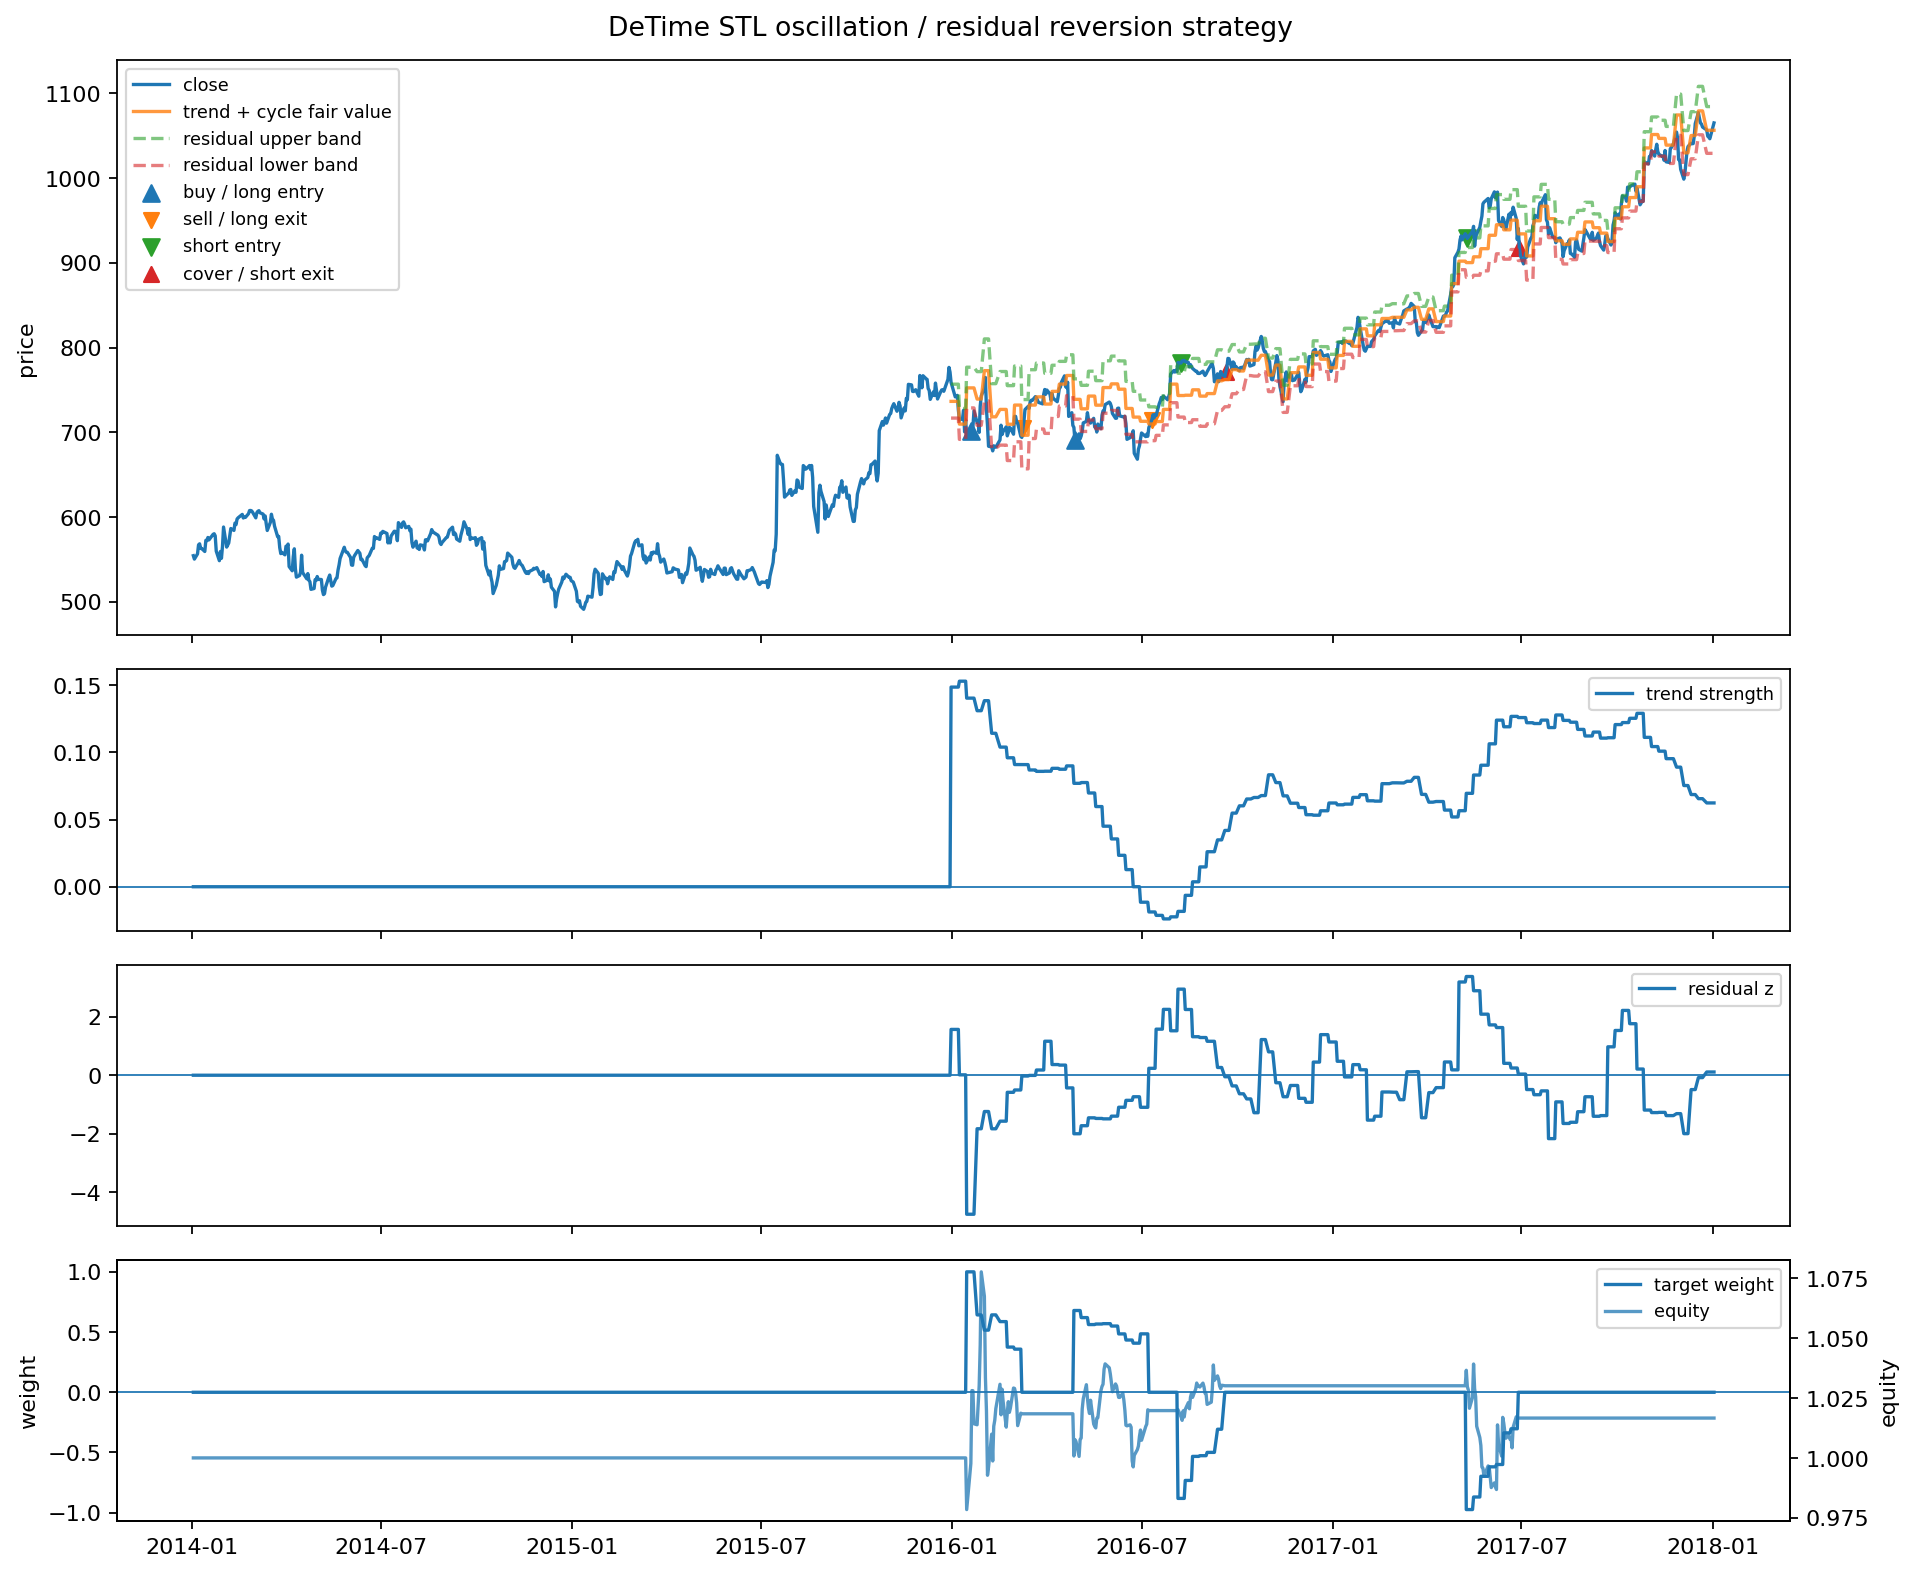

'examples/quant_trading/reports/strategy_lab/charts/notebook_02_oscillation_reversion.png'

In [7]:
out = CHART_DIR / "notebook_02_oscillation_reversion.png"
plot_signal_analysis(ohlcv, signal, bt, asset=symbol, output_path=out, title="DeTime STL oscillation / residual reversion strategy")
display(Image(filename=str(out)))
out.as_posix()